# Descriptive Analysis

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#For the EDA (Exploratory Data Analysis)

In [3]:
df_master = pd.read_csv("cardiac_failure/Team4_The_Zen_Of_Five_cleaned_data.csv")

In [4]:
print("Shape:", df_master.shape)

Shape: (2008, 200)


In [5]:
df_master.head()

,inpatient_number,gender,weight,height,bmi,occupation,agecat,flag_invalid_height,flag_invalid_weight,bmi_category,...,congestive_heart_failure,peripheral_vascular_disease,type_of_heart_failure,lvef,left_ventricular_end_diastolic_diameter_lv,mitral_valve_ems,mitral_valve_ams,ea,tricuspid_valve_return_velocity,tricuspid_valve_return_pressure
0,827040,Female,50.0,1.45,23.781213,Unspecified,69-79,False,False,Normal,...,1,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,857781,Male,50.0,1.64,18.590125,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,743087,Female,51.0,1.63,19.195303,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,40.0,1.16,1.52,NaN,3.34,47.0
3,866418,Male,70.0,1.70,24.221453,Farmer,59-69,False,False,Normal,...,0,0,Both,NaN,46.0,0.84,0.12,7.0,2.80,32.0
4,775928,Male,65.0,1.70,22.491349,Urban Resident,69-79,False,False,Normal,...,0,0,Both,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Columns: 200 entries, inpatient_number to tricuspid_valve_return_pressure
dtypes: bool(2), float64(148), int64(35), str(15)
memory usage: 3.3 MB


In [7]:
df_master.dtypes

inpatient_number                     int64
gender                                 str
weight                             float64
height                             float64
bmi                                float64
                                    ...   
mitral_valve_ems                   float64
mitral_valve_ams                   float64
ea                                 float64
tricuspid_valve_return_velocity    float64
tricuspid_valve_return_pressure    float64
Length: 200, dtype: object

# Komal's question

 Q1:What is the distribution of key lab markers — BNP, creatinine, hemoglobin, sodium, potassium — and what proportion of patients fall outside normal clinical reference ranges?

In [16]:
import pandas as pd

def pct_outside_combined(gender_col, values, ranges_by_gender):
    """Combines sex-specific reference ranges into one overall % outside, weighted correctly."""
    out, n = 0, 0
    for g, (low, high) in ranges_by_gender.items():
        v = values[(gender_col == g) & values.notna()]
        out += ((v < low) | (v > high)).sum()
        n += v.shape[0]
    return round(out / n * 100, 1), n

rows = []

# Labs with a single reference range for everyone
single_range_labs = [
    ("brain_natriuretic_peptide", 0, 100, "pg/mL", "< 100 pg/mL"),
    ("sodium", 135, 145, "mmol/L", "135-145 mmol/L"),
    ("potassium", 3.5, 5.1, "mmol/L", "3.5-5.1 mmol/L"),
]
for lab, low, high, unit, label in single_range_labs:
    s = df_master[lab].dropna()
    pct = round((((s < low) | (s > high)).mean()) * 100, 1)
    rows.append({
        "Lab": lab.replace("_", " ").title(),
        "n": s.shape[0],
        "Mean": round(s.mean(), 1),
        "Median": round(s.median(), 1),
        "IQR": round(s.quantile(0.75) - s.quantile(0.25), 1),
        "Reference range": label,
        "% Outside range": pct,
    })

# Labs with sex-specific reference ranges
gender_ranges = {
    "hemoglobin": {"Male": (130, 175), "Female": (115, 150)},
    "creatinine_enzymatic_method": {"Male": (62, 106), "Female": (44, 97)},
}
units = {"hemoglobin": "g/L", "creatinine_enzymatic_method": "umol/L"}

for lab, ranges in gender_ranges.items():
    s = df_master[lab].dropna()
    pct, n = pct_outside_combined(df_master["gender"], df_master[lab], ranges)
    rows.append({
        "Lab": lab.replace("_", " ").title(),
        "n": s.shape[0],
        "Mean": round(s.mean(), 1),
        "Median": round(s.median(), 1),
        "IQR": round(s.quantile(0.75) - s.quantile(0.25), 1),
        "Reference range": f"M {ranges['Male'][0]}-{ranges['Male'][1]} / F {ranges['Female'][0]}-{ranges['Female'][1]} {units[lab]}",
        "% Outside range": pct,
    })

table = pd.DataFrame(rows)
table
table.style.background_gradient(subset=["% Outside range"], cmap="Reds").format({"% Outside range": "{:.1f}"})

,Lab,n,Mean,Median,IQR,Reference range,% Outside range
0,Brain Natriuretic Peptide,1973,1280.400000,753.000000,1434.600000,< 100 pg/mL,92.5
1,Sodium,1997,138.200000,139.000000,5.400000,135-145 mmol/L,22.4
2,Potassium,1997,4.000000,3.900000,0.800000,3.5-5.1 mmol/L,29.6
3,Hemoglobin,1980,115.100000,117.000000,30.000000,M 130-175 / F 115-150 g/L,57.0
4,Creatinine Enzymatic Method,1985,108.900000,87.100000,57.800000,M 62-106 / F 44-97 umol/L,43.9


Findings
The gradient makes the pattern immediately visible: **Brain Natriuretic Peptide is the clear outlier**, shaded almost solid dark red at 92.5% outside range — visually distinct from every other lab in the table. Hemoglobin (57.0%) and Creatinine (43.9%) form a lighter-red middle tier,
while Sodium (22.4%) and Potassium (29.6%) sit at the pale end of the gradient, confirming electrolyte imbalance is comparatively less widespread in this cohort than cardiac stress or renal/hematologic abnormality.


Consolidating the distribution stats (n, mean, median, IQR) and the reference-range comparison into a single tidy table — one row per lab —makes the summary easier to scan than separate printouts. Adding a color gradient to the "% Outside range" column draws the eye directly to the labs with the most abnormality, without needing to read every number.

# Q2: What is the observed 6-month death rate within each combination of Killip grade level and ICU/non-ICU admission?

Why this one: It's the simple closing slide — combines two variables into one glance-able 2×2 table instead of two separate lists, which reads much stronger to judges than more text.

Key insight: Risk stacks cleanly: 1.2% (low Killip, non-ICU, n=1,547) → 8.1% (high Killip, non-ICU, n=446) → up to 16.7% in the small high-Killip+ICU cell. The robust, quotable number is the 1.2% vs 8.1% comparison — the ICU cells are too small (n=6, n=9) to lean on, so be upfront about that if asked.

In [20]:
# 6-month death rate: Killip grade × ICU admission (2×2)

In [22]:
df_master["high_killip"] = df_master["killip_grade"] >= 3
df_master["icu"] = df_master["admission_ward"] == "ICU"

grp = df_master.groupby(["high_killip", "icu"])["death_within_6_months"].agg(["count", "mean"])
grp["mean"] *= 100
print(grp)

                   count       mean
high_killip icu                    
False       False   1547   1.228184
            True       9  11.111111
True        False    446   8.071749
            True       6  16.666667


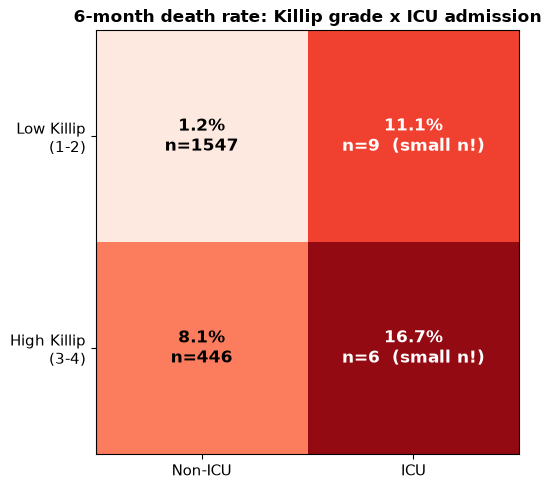

In [23]:
mat = np.array([[grp.loc[(False, False), "mean"], grp.loc[(False, True), "mean"]],
                [grp.loc[(True, False), "mean"],  grp.loc[(True, True), "mean"]]])
ns_mat = np.array([[grp.loc[(False, False), "count"], grp.loc[(False, True), "count"]],
                    [grp.loc[(True, False), "count"],  grp.loc[(True, True), "count"]]])

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(mat, cmap="Reds", vmin=0, vmax=mat.max()*1.1)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-ICU", "ICU"], fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Low Killip\n(1-2)", "High Killip\n(3-4)"], fontsize=11)
for i in range(2):
    for j in range(2):
        n = ns_mat[i, j]
        note = "  (small n!)" if n < 20 else ""
        ax.text(j, i, f"{mat[i,j]:.1f}%\nn={n}{note}", ha="center", va="center",
                fontsize=12, fontweight="bold", color="white" if mat[i,j]>mat.max()*0.5 else "black")
ax.set_title("6-month death rate: Killip grade x ICU admission", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Findings:
Death risk rises consistently across all four groups, in the direction clinical theory would predict: patients with more severe Killip class and/or ICU-levelcare carry a higher observed 6-month death rate. The step from low-Killip/non-ICU(1.2%) to high-Killip/non-ICU (8.1%) is a **6.75x** increase, and it rests on large, stable subgroups (n=1,547 and n=446) — this is the finding worth quoting with confidence.

The two ICU cells (11.1%, 16.7%) extend the same pattern further, consistent with sicker patients being triaged to the ICU. However, they are built on only 9 and 6 patients respectively, so these two numbers should be read as **directionally consistent, not statistically reliable** — a single additional death or survival in either group would shift the percentage by more than 10 points. We are reporting them for completeness and pattern-recognition, not as precise estimates.

Clinical takeaway:
Killip grade alone provides a strong, well-powered severity signal in this cohort. ICU admission status adds a second, independent severity layer that moves in the same direction, reinforcing — rather than contradicting — the Killip-grade finding. Together they support using Killip grade as a primary, low-cost triage variable, with ICU-level severity as a secondary signal that would need a larger sample before being trusted as a standalone predictor.